#Сегментация космических объектов 


## Загрузка данных

Для комфортной хагрузки данных добавьте ярлык папки Final_dataset (https://drive.google.com/drive/u/0/folders/1Q1wR9aBFCyeFEYa3wwyXNu9wk_fZdzUm) к себе на диск.

In [ ]:
#from google.colab import drive
#drive.mount('/content/drive', force_remount=True)

In [1]:
import os

# Локальный корень датасета вместо монтирования Google Drive.
BASE_PATH = r"G:\IDE\PROJECT-3_Spacecraft_Segmentation\Final_dataset"
assert os.path.isdir(BASE_PATH), f"Не найдена папка датасета: {BASE_PATH}"
print("Данные:", os.listdir(BASE_PATH))

Данные: ['images', 'ReadMe.txt', '.DS_Store', 'mask', 'all_bbox.txt']


In [ ]:
#!ls drive/MyDrive/Final_dataset

In [2]:
# Пути к папкам с изображениями и масками.
# ВАЖНО: класс SattDataset из драфта склеивает путь как `images_path + split`
# (например, images_path + "train"). Чтобы на Windows склейка давала корректный
# путь, images_path/mask_path должны заканчиваться разделителем каталога.
images_path = os.path.join(BASE_PATH, "images") + os.sep
mask_path   = os.path.join(BASE_PATH, "mask")   + os.sep

print("images:", os.path.isdir(images_path), "->", images_path)
print("mask:  ", os.path.isdir(mask_path),   "->", mask_path)

images: True -> G:\IDE\PROJECT-3_Spacecraft_Segmentation\Final_dataset\images\
mask:   True -> G:\IDE\PROJECT-3_Spacecraft_Segmentation\Final_dataset\mask\


## Импортируем нужные библиотеки

In [3]:
%%capture out
!pip install albumentations torchmetrics pytorch_lightning -U

In [4]:
%%capture
# Для mAP (segm/bbox) нужен pycocotools; torchmetrics[detection] его подтянет.
# На Windows pycocotools ставится из готового wheel (обычно без проблем).
!pip install -q "torchmetrics[detection]" pycocotools

In [5]:
import os

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pytorch_lightning as pl
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchmetrics
from albumentations.pytorch.transforms import ToTensorV2
from pytorch_lightning.callbacks import (
    EarlyStopping,
    LearningRateMonitor,
    ModelCheckpoint,
)
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm

c:\Users\Олег\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
# Модель instance segmentation и метрика mAP.
import torchvision
from torchvision.models.detection import maskrcnn_resnet50_fpn
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torchmetrics.detection.mean_ap import MeanAveragePrecision

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

device: cuda


### Проверка формата масок

Убеждаемся, что части закодированы именно цветами R/G/B. Если самые частые цвета — чистые красный/зелёный/синий (плюс чёрный фон), значит соответствие цвет→класс ниже верное. Если цвета другие — достаточно поправить словарь в функции `masks_by_part`.

маска: img_resize_0_mask.png | размер: (720, 1280, 3)
частые цвета (R,G,B) -> пикселей:
   (0, 0, 0) -> 735893
   (0, 255, 0) -> 133959
   (255, 0, 0) -> 51748


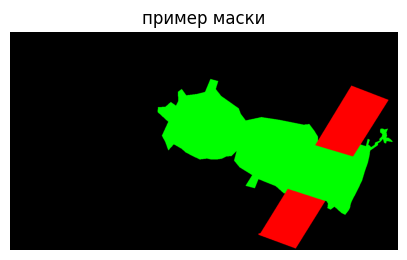

In [7]:
# Смотрим на одну маску: печатаем самые частые цвета и показываем картинку.
sample_mask_dir = mask_path + "train"
sample_name = sorted(os.listdir(sample_mask_dir))[0]
sample = cv2.cvtColor(cv2.imread(os.path.join(sample_mask_dir, sample_name)),
                      cv2.COLOR_BGR2RGB)
print("маска:", sample_name, "| размер:", sample.shape)

colors, counts = np.unique(sample.reshape(-1, 3), axis=0, return_counts=True)
print("частые цвета (R,G,B) -> пикселей:")
for i in counts.argsort()[::-1][:8]:
    print("  ", tuple(int(x) for x in colors[i]), "->", int(counts[i]))

plt.figure(figsize=(5, 3)); plt.imshow(sample)
plt.title("пример маски"); plt.axis("off"); plt.show()

### Датасет для instance segmentation

Mask R-CNN на каждый объект (инстанс) ждёт: бинарную маску, ограничивающий бокс и метку класса. Поэтому из **одной цветной маски** мы достаём **до трёх инстансов** — по одному на присутствующую часть аппарата.

In [8]:
# --- Соответствие: цвет части -> класс ------------------------------------
# зелёный  -> корпус          (body)
# красный  -> солнечная панель (solar panel)
# синий    -> антенна          (antenna)
# Классы Mask R-CNN нумеруются с 1, 0 = фон.
CLASS_NAMES = {0: "background", 1: "body", 2: "solar_panel", 3: "antenna"}
NUM_CLASSES = 4  # фон + 3 части

_COLOR_THR = 50  # порог: канал выше него считаем 'активным' (отсекаем чёрный фон)


def masks_by_part(mask_rgb):
    """Из цветной маски RGB делает по одной бинарной маске на каждую часть.

    Пиксель относим к части по доминирующему каналу (R->панель, G->корпус,
    B->антенна), но только там, где пиксель не чёрный (есть объект).
    Возвращает (список бинарных масок uint8, список меток классов).
    """
    foreground = mask_rgb.max(axis=2) > _COLOR_THR   # где вообще есть объект
    argmax_ch = mask_rgb.argmax(axis=2)              # 0=R, 1=G, 2=B

    # доминирующий канал -> метка класса
    ch_to_label = {0: 2, 1: 1, 2: 3}                 # R->панель, G->корпус, B->антенна

    masks, labels = [], []
    for ch, label in ch_to_label.items():
        part = (foreground & (argmax_ch == ch)).astype(np.uint8)
        if part.sum() > 0:                           # часть присутствует на фото
            masks.append(part)
            labels.append(label)
    return masks, labels


_IMG_EXT = (".jpg", ".jpeg", ".png", ".bmp")


def list_images(folder):
    """Файлы-картинки из папки, без скрытого мусора вроде .DS_Store."""
    return sorted(f for f in os.listdir(folder)
                  if f.lower().endswith(_IMG_EXT) and not f.startswith("."))


def file_index(name):
    """Числовой индекс из имени файла: 'img_resize_12.jpg' -> 12.

    Имена картинок и масок различаются ('img_resize_0' vs, например, '0'),
    но общий у них — номер. По нему и сопоставляем пары.
    """
    import re
    nums = re.findall(r"\d+", name)
    return int(nums[-1]) if nums else None


class SattDataset(Dataset):
    def __init__(self, split="train", transform=None):
        # Имена файлов берём из подпапок images/<split> и mask/<split>,
        # отфильтровав служебные файлы (например, .DS_Store от macOS).
        self.images_filenames = list_images(images_path + split)
        self.mask_filenames = list_images(mask_path + split)
        self.split = split
        self.transform = transform

        # Маску сопоставляем картинке по числовому индексу в имени —
        # надёжнее, чем по полному имени (имена картинок и масок различаются).
        self._mask_by_index = {file_index(m): m for m in self.mask_filenames}

    def __len__(self):
        return len(self.images_filenames)

    def __getitem__(self, idx):
        img_name = self.images_filenames[idx]
        key = file_index(img_name)
        assert key in self._mask_by_index, f"нет маски для {img_name} (индекс {key})"
        mask_name = self._mask_by_index[key]

        # cv2 читает в BGR -> переводим в RGB
        image = cv2.cvtColor(cv2.imread(os.path.join(images_path + self.split, img_name)),
                             cv2.COLOR_BGR2RGB)
        mask_rgb = cv2.cvtColor(cv2.imread(os.path.join(mask_path + self.split, mask_name)),
                                cv2.COLOR_BGR2RGB)

        # по цветам -> список бинарных масок и меток
        inst_masks, inst_labels = masks_by_part(mask_rgb)

        # аугментации/ресайз (Albumentations трансформирует и список масок)
        if self.transform is not None:
            out = self.transform(image=image, masks=inst_masks)
            image = out["image"]          # тензор C×H×W в [0,1]
            inst_masks = out["masks"]      # список тензоров H×W
        else:
            image = torch.from_numpy(image).permute(2, 0, 1).float() / 255.0
            inst_masks = [torch.from_numpy(m) for m in inst_masks]

        # собираем target в формате torchvision
        boxes, labels, masks = [], [], []
        for m, lab in zip(inst_masks, inst_labels):
            m = (m > 0).to(torch.uint8)
            ys, xs = torch.where(m)
            if xs.numel() == 0:            # маска 'схлопнулась' после ресайза
                continue
            x1, x2 = xs.min().item(), xs.max().item()
            y1, y2 = ys.min().item(), ys.max().item()
            if x2 <= x1 or y2 <= y1:       # вырожденный бокс — пропускаем
                continue
            boxes.append([x1, y1, x2, y2]); labels.append(lab); masks.append(m)

        _, H, W = image.shape
        if len(boxes) == 0:                # объектов не осталось
            target = {
                "boxes": torch.zeros((0, 4), dtype=torch.float32),
                "labels": torch.zeros((0,), dtype=torch.int64),
                "masks": torch.zeros((0, H, W), dtype=torch.uint8),
                "image_id": torch.tensor([idx]),
                "area": torch.zeros((0,), dtype=torch.float32),
                "iscrowd": torch.zeros((0,), dtype=torch.int64),
            }
        else:
            boxes = torch.tensor(boxes, dtype=torch.float32)
            target = {
                "boxes": boxes,
                "labels": torch.tensor(labels, dtype=torch.int64),
                "masks": torch.stack(masks).to(torch.uint8),
                "image_id": torch.tensor([idx]),
                "area": (boxes[:, 3] - boxes[:, 1]) * (boxes[:, 2] - boxes[:, 0]),
                "iscrowd": torch.zeros((len(boxes),), dtype=torch.int64),
            }
        return image, target

In [9]:
# Быстрая проверка датасета без аугментаций.
train_dataset = SattDataset()
val_dataset = SattDataset(split="val")
print("train:", len(train_dataset), "| val:", len(val_dataset))

img, target = train_dataset[0]
print("image:", img.shape, img.dtype)
print("объектов на первом фото:", len(target["labels"]),
      "| классы:", target["labels"].tolist())

train: 2517 | val: 600
image: torch.Size([3, 720, 1280]) torch.float32
объектов на первом фото: 2 | классы: [2, 1]


In [10]:
def display_few_examples_from_data(dataset, n=4):
    """Рисует n примеров: изображение + наложенные маски частей и боксы."""
    part_colors = {1: (0, 1, 0), 2: (1, 0, 0), 3: (0, 0, 1)}  # корпус/панель/антенна

    n = min(n, len(dataset))
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]

    for ax, idx in zip(axes, range(n)):
        image, target = dataset[idx]
        img = np.clip(image.permute(1, 2, 0).cpu().numpy(), 0, 1)  # C×H×W -> H×W×C

        overlay = img.copy()
        for m, lab in zip(target["masks"], target["labels"].tolist()):
            mask = m.cpu().numpy().astype(bool)
            color = np.array(part_colors.get(lab, (1, 1, 0)))
            overlay[mask] = 0.5 * overlay[mask] + 0.5 * color      # полупрозрачно

        ax.imshow(overlay)
        for (x1, y1, x2, y2), lab in zip(target["boxes"].tolist(),
                                         target["labels"].tolist()):
            ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1,
                                       fill=False, edgecolor="white", lw=1.5))
            ax.text(x1, max(0, y1 - 3), CLASS_NAMES[lab], color="white",
                    fontsize=8, backgroundcolor="black")
        ax.set_title(f"пример #{idx}"); ax.axis("off")
    plt.tight_layout(); plt.show()

### Выбираем аугментации для обучения

Вы можете заменить аугментацию на ваш выбор

In [11]:
# ВАЖНО: Mask R-CNN сам нормализует вход статистиками ImageNet, поэтому здесь
# мы НЕ вычитаем ImageNet mean/std, а лишь приводим пиксели к [0,1]
# (Normalize с mean=0, std=1, max_pixel_value=255). Иначе будет двойная нормализация.
train_transform = A.Compose(
    [
        A.Resize(512, 512),
        A.HorizontalFlip(p=0.5),
        A.RandomBrightnessContrast(brightness_limit=0.2, contrast_limit=0.2, p=0.5),
        A.Normalize(mean=(0, 0, 0), std=(1, 1, 1), max_pixel_value=255.0),
        ToTensorV2(),
    ]
)

val_transform = A.Compose(
    [
        A.Resize(512, 512),
        A.Normalize(mean=(0, 0, 0), std=(1, 1, 1), max_pixel_value=255.0),
        ToTensorV2(),
    ]
)

# Пересоздаём датасеты уже с трансформациями.
train_dataset = SattDataset("train", transform=train_transform)
val_dataset = SattDataset("val", transform=val_transform)

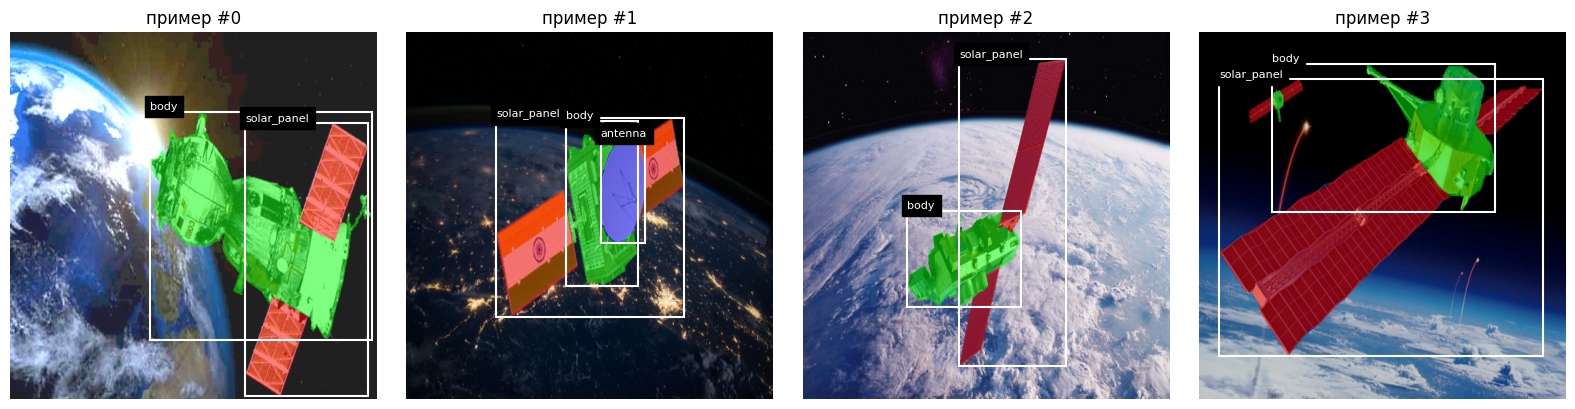

Validation dataset


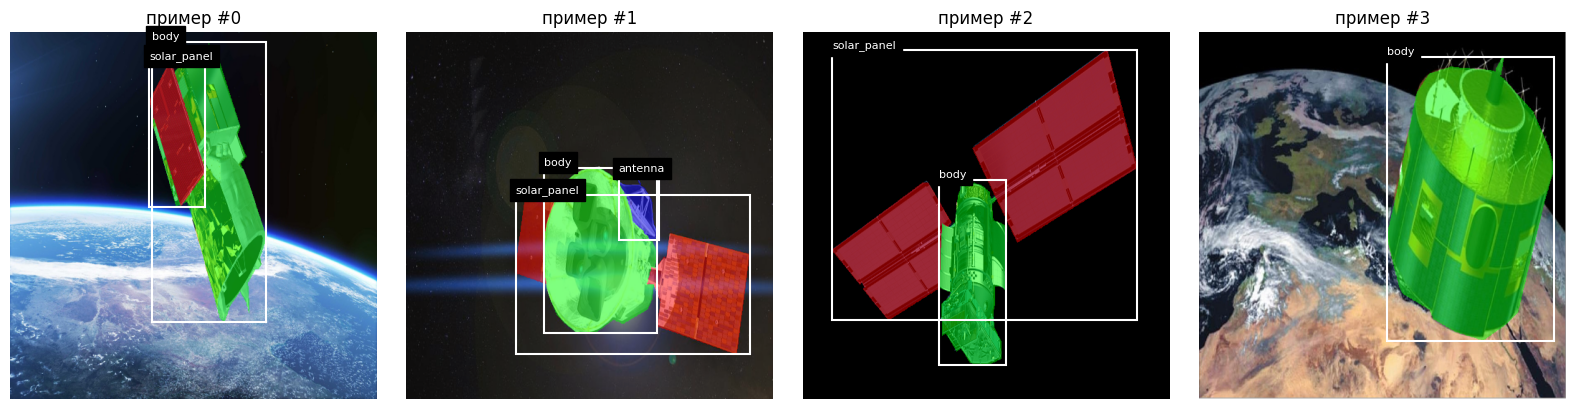

In [12]:
display_few_examples_from_data(train_dataset)
print("Validation dataset")
display_few_examples_from_data(val_dataset)

## Обучение модели

 
1.   Реализуйте выбранную вами модели instance segmentation
2.   Обучите модель
3.   Сравните разные метрики instance segmentation, включая mIoU


In [13]:
def build_model(num_classes=NUM_CLASSES):
    """Mask R-CNN (ResNet50-FPN), предобученный на COCO, с заменёнными головами."""
    model = maskrcnn_resnet50_fpn(weights="DEFAULT")  # первый запуск качает веса (~170 МБ)

    # заменяем классификатор боксов под наше число классов
    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    # заменяем предсказатель масок
    in_feat_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_feat_mask, 256, num_classes)

    # вход уже 512×512 — фиксируем размер, чтобы модель не растягивала до 800 (экономим VRAM)
    model.transform.min_size = (512,)
    model.transform.max_size = 512
    return model


model = build_model().to(device)
print("классов (с фоном):", NUM_CLASSES)

Downloading: "https://download.pytorch.org/models/maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth" to C:\Users\Олег/.cache\torch\hub\checkpoints\maskrcnn_resnet50_fpn_coco-bf2d0c1e.pth
100%|██████████| 170M/170M [00:24<00:00, 7.19MB/s] 


классов (с фоном): 4


In [14]:
def collate_fn(batch):
    # для детекции батч — это список (image, target), а не стек тензоров
    return tuple(zip(*batch))

# num_workers=0 обязателен на Windows, иначе падает multiprocessing DataLoader.
train_loader = DataLoader(train_dataset, batch_size=2, shuffle=True,
                          num_workers=0, collate_fn=collate_fn)
val_loader = DataLoader(val_dataset, batch_size=2, shuffle=False,
                        num_workers=0, collate_fn=collate_fn)
print("батчей: train =", len(train_loader), "| val =", len(val_loader))

батчей: train = 1259 | val = 300


In [15]:
# --- обучение (обычный цикл PyTorch — так нагляднее для детекции) -----------
NUM_EPOCHS = 10
params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.AdamW(params, lr=1e-4, weight_decay=1e-4)
lr_scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=4, gamma=0.5)

# смешанная точность экономит память на 12 ГБ и ускоряет обучение
use_amp = device.type == "cuda"
scaler = torch.cuda.amp.GradScaler(enabled=use_amp)

for epoch in range(NUM_EPOCHS):
    model.train()
    running = 0.0
    pbar = tqdm(train_loader, desc=f"epoch {epoch + 1}/{NUM_EPOCHS}")
    for images, targets in pbar:
        images = [img.to(device) for img in images]
        targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

        optimizer.zero_grad()
        with torch.cuda.amp.autocast(enabled=use_amp):
            loss_dict = model(images, targets)  # в train-режиме модель возвращает лоссы
            loss = sum(loss_dict.values())

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running += loss.item()
        pbar.set_postfix(loss=f"{loss.item():.3f}")

    lr_scheduler.step()
    print(f"epoch {epoch + 1}: средний loss = {running / len(train_loader):.4f}")

# сохраняем веса (ASCII-путь на G:, чтобы не задеть кириллический C:\\Users\\Олег)
ckpt_path = os.path.join(BASE_PATH, "maskrcnn_spacecraft.pth")
torch.save(model.state_dict(), ckpt_path)
print("сохранено:", ckpt_path)

C:\Users\Олег\AppData\Local\Temp\ipykernel_23760\1944161124.py:9: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=use_amp)
epoch 1/10:   0%|          | 0/1259 [00:00<?, ?it/s]C:\Users\Олег\AppData\Local\Temp\ipykernel_23760\1944161124.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
epoch 1/10: 100%|██████████| 1259/1259 [08:24<00:00,  2.49it/s, loss=0.554]


epoch 1: средний loss = 0.6223


epoch 2/10: 100%|██████████| 1259/1259 [05:18<00:00,  3.95it/s, loss=0.325]


epoch 2: средний loss = 0.5078


epoch 3/10: 100%|██████████| 1259/1259 [05:21<00:00,  3.92it/s, loss=0.709]


...

epoch 8: средний loss = 0.2840


epoch 9/10: 100%|██████████| 1259/1259 [05:21<00:00,  3.92it/s, loss=0.147]


epoch 9: средний loss = 0.2497


epoch 10/10: 100%|██████████| 1259/1259 [05:23<00:00,  3.89it/s, loss=0.111]


epoch 10: средний loss = 0.2342
сохранено: G:\IDE\PROJECT-3_Spacecraft_Segmentation\Final_dataset\maskrcnn_spacecraft.pth


## Метрики instance segmentation

Считаем две группы метрик:

- **mAP (segm)** — стандартная метрика instance segmentation (COCO-style).
- **mIoU** — усреднённый IoU. Приводим инстансы к семантической карте по классам и считаем IoU по каждому классу; отдельно — **foreground mIoU** (аппарат целиком vs фон), который обычно и сравнивают с порогом **0.70**.

In [16]:
SCORE_THR = 0.5  # порог уверенности для перевода предсказаний в маски

def semantic_from_instances(masks, labels, H, W):
    """Собирает семантическую карту (NUM_CLASSES×H×W) из инстансов."""
    sem = torch.zeros((NUM_CLASSES, H, W), dtype=torch.bool)
    for m, lab in zip(masks, labels):
        sem[int(lab)] |= m.bool()
    return sem

map_metric = MeanAveragePrecision(iou_type="segm")
inter = torch.zeros(NUM_CLASSES); union = torch.zeros(NUM_CLASSES)  # для mIoU по классам
fg_inter = 0.0; fg_union = 0.0                                      # для foreground mIoU

model.eval()
with torch.no_grad():
    for images, targets in tqdm(val_loader, desc="оценка"):
        preds = model([img.to(device) for img in images])

        preds_fmt, gts_fmt = [], []
        for pred, gt, img in zip(preds, targets, images):
            keep = pred["scores"] >= SCORE_THR
            p_masks = (pred["masks"][keep, 0] > 0.5).cpu()   # N×H×W bool
            p_labels = pred["labels"][keep].cpu()
            preds_fmt.append({"masks": p_masks,
                              "scores": pred["scores"][keep].cpu(),
                              "labels": p_labels})
            gts_fmt.append({"masks": gt["masks"].bool(), "labels": gt["labels"]})

            # --- накопление IoU ---
            _, H, W = img.shape
            sem_p = semantic_from_instances(p_masks, p_labels, H, W)
            sem_g = semantic_from_instances(gt["masks"], gt["labels"], H, W)
            for c in range(1, NUM_CLASSES):
                inter[c] += (sem_p[c] & sem_g[c]).sum().item()
                union[c] += (sem_p[c] | sem_g[c]).sum().item()
            fg_p = sem_p[1:].any(0); fg_g = sem_g[1:].any(0)
            fg_inter += (fg_p & fg_g).sum().item()
            fg_union += (fg_p | fg_g).sum().item()

        map_metric.update(preds_fmt, gts_fmt)

# --- mAP (может требовать pycocotools) ---
try:
    m = map_metric.compute()
    print(f"mAP (segm)   : {float(m['map']):.3f}")
    print(f"mAP@0.50     : {float(m['map_50']):.3f}")
except Exception as e:
    print("mAP не посчитан (проверьте pycocotools):", e)

# --- mIoU по частям ---
print("\nIoU по частям:")
ious = []
for c in range(1, NUM_CLASSES):
    if union[c] > 0:
        iou_c = (inter[c] / union[c]).item()
        ious.append(iou_c)
        print(f"  {CLASS_NAMES[c]:12s}: {iou_c:.3f}")
if ious:
    print(f"\nmIoU (по частям)      : {sum(ious) / len(ious):.3f}")

# --- foreground mIoU (обычно сравнивают с 0.70) ---
if fg_union > 0:
    print(f"mIoU (аппарат vs фон) : {fg_inter / fg_union:.3f}")

оценка: 100%|██████████| 300/300 [02:13<00:00,  2.25it/s]


mAP (segm)   : 0.437
mAP@0.50     : 0.710

IoU по частям:
  body        : 0.764
  solar_panel : 0.804
  antenna     : 0.490

mIoU (по частям)      : 0.686
mIoU (аппарат vs фон) : 0.881


## Визуализация предсказаний

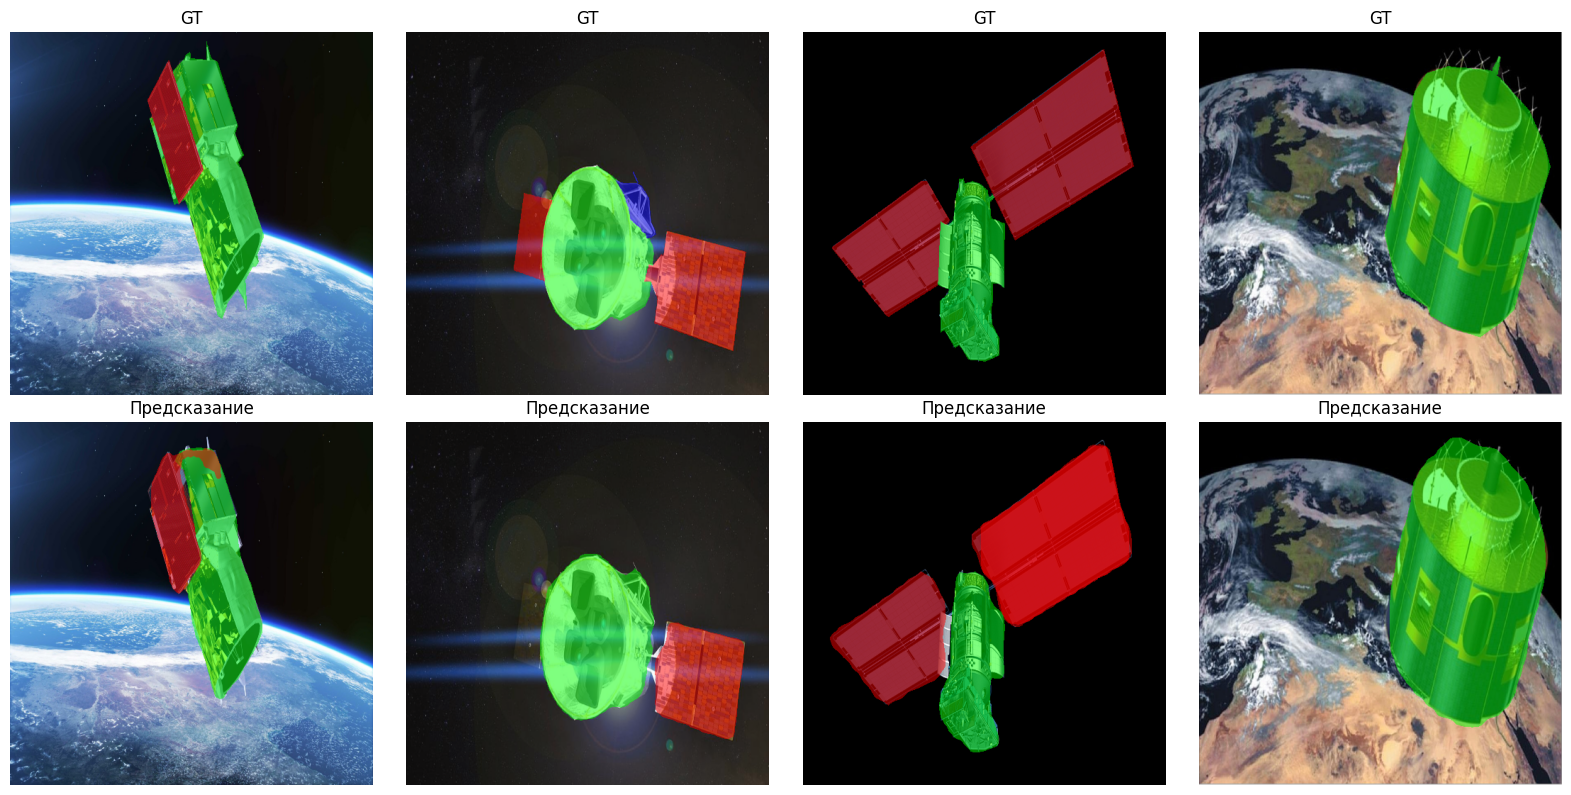

In [18]:
# Верхний ряд — разметка (GT), нижний — предсказания модели.
part_colors = {1: (0, 1, 0), 2: (1, 0, 0), 3: (0, 0, 1)}

def overlay_masks(img, masks, labels):
    out = img.copy()
    for m, lab in zip(masks, labels):
        binm = m.astype(bool)
        out[binm] = 0.5 * out[binm] + 0.5 * np.array(part_colors.get(int(lab), (1, 1, 0)))
    return out

model.eval()
n_show = 4
fig, axes = plt.subplots(2, n_show, figsize=(4 * n_show, 8))
with torch.no_grad():
    for j in range(n_show):
        image, target = val_dataset[j]
        pred = model([image.to(device)])[0]
        img = np.clip(image.permute(1, 2, 0).cpu().numpy(), 0, 1)

        gt = overlay_masks(img, [m.cpu().numpy() for m in target["masks"]],
                           target["labels"].tolist())
        axes[0, j].imshow(gt); axes[0, j].axis("off"); axes[0, j].set_title("GT")

        keep = pred["scores"] >= SCORE_THR
        pm = [(m[0] > 0.5).cpu().numpy() for m in pred["masks"][keep]]
        pr = overlay_masks(img, pm, pred["labels"][keep].tolist())
        axes[1, j].imshow(pr); axes[1, j].axis("off"); axes[1, j].set_title("Предсказание")
plt.tight_layout(); plt.show()